## Q1

In [ ]:
from PIL import Image
import numpy as np

# loading image
img = Image.open("dog.jpg")
img_array = np.array(img)

array([[[ 89,  89,  89],
        [ 88,  88,  88],
        [ 88,  88,  88],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 60,  60,  60]],

       [[ 89,  89,  89],
        [ 89,  89,  89],
        [ 88,  88,  88],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 60,  60,  60]],

       [[ 90,  90,  90],
        [ 89,  89,  89],
        [ 89,  89,  89],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 61,  61,  61]],

       ...,

       [[144, 144, 144],
        [144, 144, 144],
        [145, 145, 145],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]],

       [[144, 144, 144],
        [144, 144, 144],
        [147, 147, 147],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]],

       [[144, 144, 144],
        [145, 145, 145],
        [149, 149, 149],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]]], dtype=uint8)
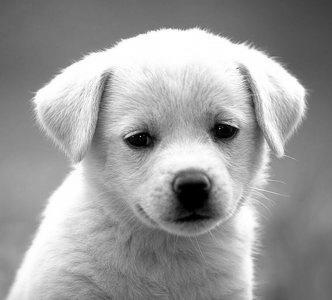

In [ ]:
img_array

In [ ]:
img_array.dtype

dtype('uint8')

In [ ]:
# converting it from uint to float to prevent data type errors
img_array = img_array.astype(np.float32)

In [ ]:
# generating noise and making sure that datatype and shape matches to og image
noise = np.random.normal(0, 15, img_array.shape).astype(img_array.dtype)

In [ ]:
noise.shape

(300, 332, 3)

In [ ]:
noise.dtype

dtype('float32')

In [ ]:
# adding noise
noisy_img = img_array + noise

In [ ]:
# clipping the value if it goes outside 0 or 255
noisy_img = np.clip(noisy_img, 0, 255)

In [ ]:
# converting back to uint8
noisy_img = noisy_img.astype(np.uint8)

array([[[ 94, 100,  63],
        [ 92,  81,  67],
        [104, 101,  79],
        ...,
        [ 52,  67,  79],
        [ 69,  59,  65],
        [ 45,  45,  81]],

       [[ 85,  98,  96],
        [ 68,  73,  83],
        [ 49, 104,  77],
        ...,
        [ 47,  92,  83],
        [ 76,  23,  70],
        [ 82,  70,  45]],

       [[ 99,  80,  69],
        [ 79,  81,  68],
        [ 74,  75,  63],
        ...,
        [ 85,  32,  90],
        [ 39,  68,  90],
        [ 59,  53,  31]],

       ...,

       [[152, 168, 134],
        [132, 152, 140],
        [144, 122, 128],
        ...,
        [ 78,  68, 107],
        [102, 119, 108],
        [ 92, 121,  94]],

       [[149, 144, 153],
        [128, 156, 150],
        [134, 124, 131],
        ...,
        [109, 104, 103],
        [118, 120,  85],
        [113, 105, 117]],

       [[144, 127, 145],
        [131, 153, 143],
        [164, 135, 158],
        ...,
        [127, 106,  94],
        [113, 104, 112],
        [125,  96,  88]]], dtype=uint8)
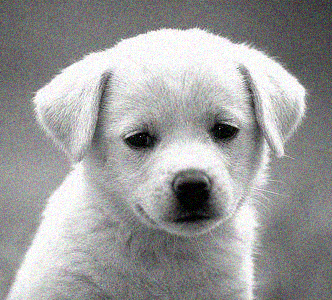

In [ ]:
noisy_img

## Q2

In [ ]:
kernel = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])

In [ ]:
flipped_kernel = np.flip(kernel)

In [ ]:
# getting inaccurate result on RGB image because of sobel kernel, therefore using grayscale image
img = Image.open("dog.jpg").convert("L")
image = np.array(img).astype(np.float32)

In [ ]:
# we don't pad color channels
padded = np.pad(image,((1,1),(1,1)), mode='constant',constant_values=0)

In [ ]:
padded

array([[  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,  89.,  88., ...,  61.,  60.,   0.],
       [  0.,  89.,  89., ...,  61.,  60.,   0.],
       ...,
       [  0., 144., 144., ..., 103., 102.,   0.],
       [  0., 144., 145., ..., 103., 102.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.]], dtype=float32)

In [ ]:
output = np.zeros(image.shape)

In [ ]:
for i in range(256):
    for j in range(256):
        patch = padded[i:i+3, j:j+3]
        output[i,j] = np.sum(patch * flipped_kernel)


In [ ]:
output = np.clip(output, 0, 255)
output = output.astype(np.uint8)

array([[255,   0,   0, ...,   0,   0,   0],
       [255,   0,   0, ...,   0,   0,   0],
       [255,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
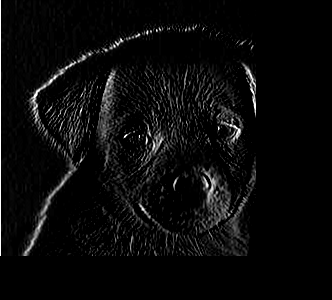

In [ ]:
output

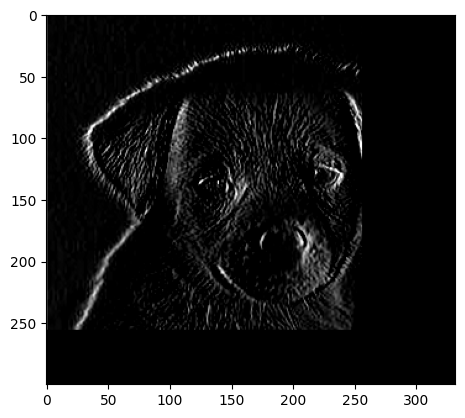

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(output, cmap='gray')
plt.show()

## Q3

In [ ]:
img = Image.open("dog.jpg")
image = np.array(img).astype(np.float32)

In [ ]:
image.shape

(300, 332, 3)

In [ ]:
H, W, C = image.shape

Denoising using Gaussian Kernel

In [ ]:
size = 7
sigma = 1.0
k = size // 2  # floor division

# Create Gaussian kernel
x = np.arange(-k, k+1)
y = np.arange(-k, k+1)
x, y = np.meshgrid(x, y)

kernel = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))
# normalizing kernel
kernel = kernel / np.sum(kernel)

In [ ]:
output = np.zeros((H, W, C))

In [ ]:
padded = np.pad(image, ((k,k),(k,k),(0,0)), mode='constant')

In [ ]:
for c in range(C):
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+size, j:j+size, c]
            output[i,j,c] = np.sum(patch * kernel)

In [ ]:
output = np.clip(output, 0, 255).astype(np.uint8)

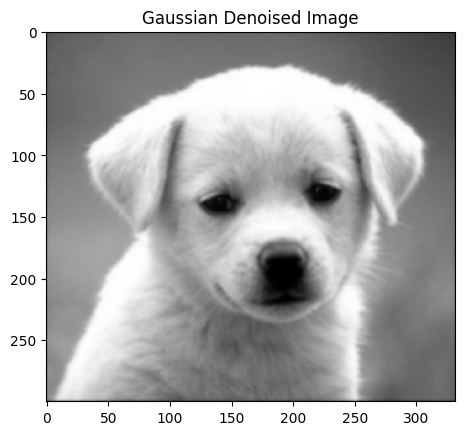

In [ ]:
plt.imshow(output)
plt.title("Gaussian Denoised Image")
plt.show()

sharpening the image

In [ ]:
sharpening_kernel = np.array([
        [1, 4, 6, 4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, -476, 24, 6],
        [4, 16, 24, 16, 4],
        [1, 4, 6, 4, 1]
    ], dtype=np.float32) * (-1.0 / 256.0)

In [ ]:
padded = np.pad(output.astype(np.float32), ((k,k),(k,k),(0,0)), mode='constant')
sharp = np.zeros((H, W, C))

In [ ]:
for c in range(C):
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+5, j:j+5, c]
            sharp[i,j,c] = np.sum(patch * sharpening_kernel)

In [ ]:
sharp = np.clip(sharp, 0, 255).astype(np.uint8)

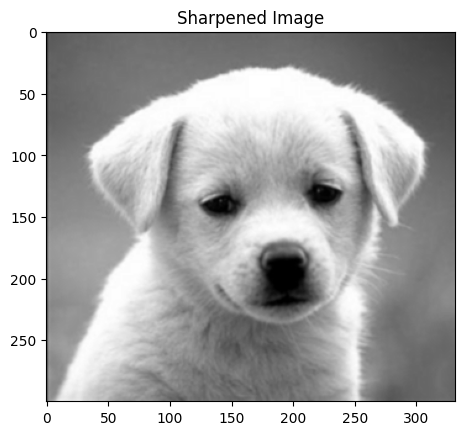

In [ ]:
plt.imshow(sharp)
plt.title("Sharpened Image")
plt.show()

## Q4

In [ ]:
shelf = np.array(Image.open("shelf.jpg")).astype(np.float32)
template = np.array(Image.open("template.jpg")).astype(np.float32)

In [ ]:
shelf.shape

(400, 1000, 3)

In [ ]:
template.shape

(56, 39, 3)

In [ ]:
Hs, Ws, Cs = shelf.shape
Ht, Wt, Ct = template.shape

Convolution Matching

In [ ]:
# Subtracting mean from template to prevent bias towards white regions
template = template - np.mean(template)

In [ ]:
# in convolution we flip the kernel
template_flipped = np.flip(template)

In [ ]:
# convolution output shape = I-K+1
result = np.zeros((Hs - Ht + 1, Ws - Wt + 1))

In [ ]:
for i in range(Hs - Ht + 1):
    for j in range(Ws - Wt + 1):
        patch = shelf[i:i+Ht, j:j+Wt, :]
        patch = patch - np.mean(patch)

        result[i, j] = np.sum(patch * template_flipped)

In [ ]:
# Locating the best match
y, x = np.unravel_index(np.argmax(result), result.shape)

In [ ]:
print("The template's Best match is at:", y, x)


The template's Best match is at: 71 524


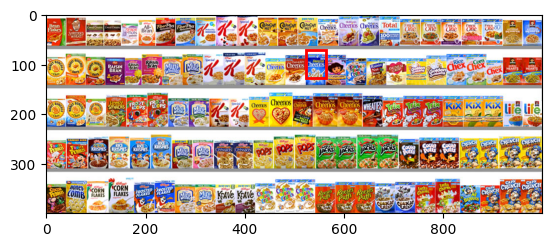

In [ ]:
# Draw rectangle
plt.imshow(shelf.astype(np.uint8))
plt.gca().add_patch(
    plt.Rectangle((x, y), Wt, Ht,
                  edgecolor='red', fill=False, linewidth=2)
)
plt.show()

Correlation matching

In [ ]:
template = template - np.mean(template)

In [ ]:
for i in range(Hs - Ht + 1):
    for j in range(Ws - Wt + 1):
        patch = shelf[i:i+Ht, j:j+Wt, :]

        patch = patch - np.mean(patch)

        result[i, j] = np.sum(patch * template)


In [ ]:
y, x = np.unravel_index(np.argmax(result), result.shape)
print("Best match at:", y, x)

Best match at: 8 41


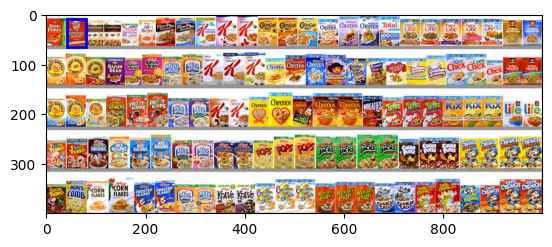

In [ ]:
plt.imshow(shelf.astype(np.uint8))
plt.gca().add_patch(
    plt.Rectangle((x, y), Wt, Ht,edgecolor='blue', fill=False, linewidth=2))
plt.show()

part e: Correlation. Because it preserves the original template image orientation and measures direct similarty. While convolution flips the template which changes the pattern direction and hence it doesnt give accurate result.

part f: Though the both the convolution and correlation will have same computational complexity.But correlation is slightly simpler because of no flip step

part g: Correlation is better for this use case because template orientation must match original object and correlation preserves the original structure unlike convolution. Convolution might be better if we were asked to detect patterns.

part h: As you can see above in the results, the correlation approach was more effective, accurate and simpler

### different approach for convolutional matching

In [77]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

shelf = cv2.imread('shelf.jpg', cv2.IMREAD_GRAYSCALE)
template = cv2.imread('template.jpg', cv2.IMREAD_GRAYSCALE)

H, W = shelf.shape
h, w = template.shape

shelf = shelf - np.mean(shelf)
template = template - np.mean(template)

template_flip = np.flip(np.flip(template))

result_conv = np.zeros((H - h + 1, W - w + 1))

for i in range(H - h + 1):
    for j in range(W - w + 1):
        region = shelf[i:i+h, j:j+w]
        result_conv[i, j] = np.sum(region * template_flip)

y_conv, x_conv = np.unravel_index(np.argmax(result_conv), result_conv.shape)
print("Best match at:", y_conv, x_conv)


Best match at: 8 41


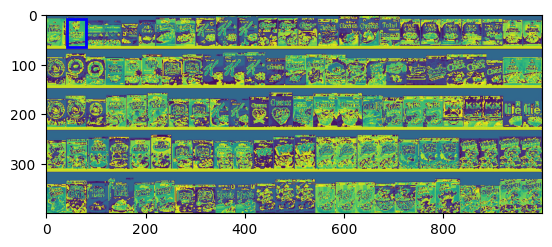

In [79]:
plt.imshow(shelf.astype(np.uint8))
plt.gca().add_patch(
    plt.Rectangle((x, y), Wt, Ht,edgecolor='blue', fill=False, linewidth=2))
plt.show()

converted the image into the gray scale and then applied convolution matching and it worked.